<a href="https://colab.research.google.com/github/ProshkinNV/Image/blob/main/VAE%20Generation%20%E2%84%964.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Variational Autoencoder (VAE)

Работу выполнил студент Группы № 9 Прошкин Н.В.

Аннотация:


Применение VAE для генерации изображений в конкретной предметной области (например, медицинских снимков, лиц знаменитостей).

Установка и импорт библиотек


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from matplotlib.image import imread
%matplotlib inline

#вспомогательные библиотеки
import kagglehub

### Краткое описание исследования:


Генеративные модели используют для того, чтобы производить случайные выходные данные, которые выглядят схоже с тренировочным набором данных, и тоже самое вы можете делать с помощью VAEs. Однако зачастую необходимо изменить или исследовать вариации на данных, которые уже имеются, и не случайным образом, а определённым желаемым способом. В этом случае VAEs работают лучше, чем любой другой ныне доступный метод.

#### Основой VAE является:

Нейросеть автоэнкодера на самом деле является парой из двух соединенных нейросетей – энкодера и декодера

Энкодер - принимает входные данные и преобразует их, делая представление более компактным и сжатым.

Декодер - использует преобразованные данные для трансформации их обратно в оригинальное состояние.

Однако, вариационный автоэнкодер (VAE) имеет одно уникальное свойство, которое отличает его от стандартного автоэнкодера. Именно это свойство делает вариационные автоэнкодеры столь полезными при генерации данных: их скрытое пространство по построению является непрерывным, позволяя выполнять случайные преобразования и интерполяцию.

Непрерывность скрытого пространства достигается неожиданным способом: энкодер выдаёт не один вектор размера n, а два вектора размера n – вектор средних значений µ и вектор стандартных отклонений σ.






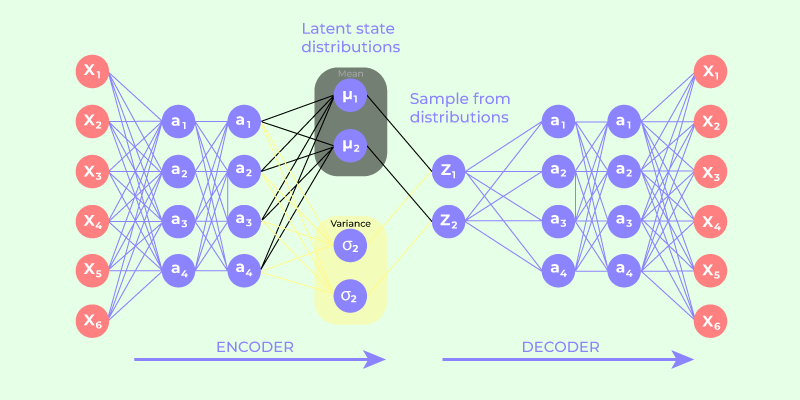

*Схема архитектуры*

###Математические основы вариационного автоэнкодера

Необходимо, чтобы модель максимизировала правдоподобие p(x) элементов обучающего множества
D при описанной процедуре генерации:

$$p(x)=\int\limits_{Z^M}p(x∣z)p(z)dz→max$$


Предположим, что совместное распределение
$p
(x,z)$ параметризовано некоторым параметром
$θ∈Θ$ и выражается непрерывной по
$θ$ функцией при каждых фиксированных
$x$ и $z$:

Тогда
$$pθ​(x,z)=p(x∣z,θ)p(z∣θ)=pθ(x∣z)pθ(z)$$

можно записать следующую задачу оптимизации:
$$pθ(x)=\int\limits_{Z^M} pθ(x∣z)pθ(z)dz→\max\limits_{θ∈Θ}$$

###Подготовка данных

Загрузка датасэта

In [ ]:
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

100%|██████████| 1.33G/1.33G [00:15<00:00, 94.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


Предобработка данных

Вспомогательная функция загрузки изображений

In [ ]:
def load_image(root_dir: str, dir_name: str, file_name: str, extension: str) -> Image:
    return Image.open(
        os.path.join(
            root_dir,
            dir_name,
            file_name + extension
        )
    )

In [ ]:
transform_input = transforms.Compose([
    transforms.Resize((32, 32))
    #transforms.Normalize(
    #    mean=[0.5, 0.5, 0,5],
    #    std=[0.25, 0.25, 0.25]
    #)
])

transform_output = transforms.Compose([
    transforms.Resize((32, 32))
    #transforms.Normalize(
    #    mean=[0.5, 0.5, 0,5],
    #    std=[0.25, 0.25, 0.25]
    #)
])

Класс предобработки изображений

In [ ]:
class PreprocessDataset(Dataset):
  def __init__(self, dir, transform_input=None, transform_output=None):
    super().__init__()
    self.root = dir

    self.transform_input = transform_input
    self.transform_output = transform_output

    self.list_of_inputs = os.listdir(dir)

  def __getitem__(self, idx):
    to_tensor_transform = transforms.ToTensor()

    input_image = load_image(self.root, r"", self.list_of_inputs[idx], "")
    input_image = to_tensor_transform(input_image)
    target_image = input_image

    if self.transform_input:
      input_image = self.transform_input(input_image)

    if self.transform_output:
      target_image = self.transform_output(target_image)

    return input_image.float(), target_image.float()

  def __len__(self):
        return len(self.list_of_inputs)

In [ ]:
batch_size_train = 64
path_to_dir = path + "/img_align_celeba/img_align_celeba"
train_dataset = PreprocessDataset(path_to_dir, transform_input=transform_input, transform_output=transform_output) #Использование класса предобработки изображений

Визуализация данных

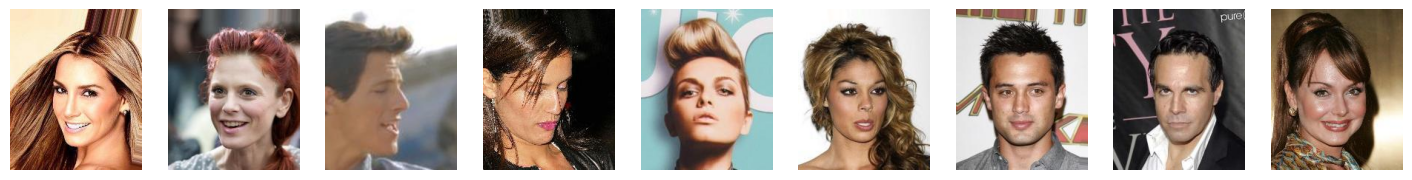

In [ ]:
plt.figure(figsize=(20,20))
plt.subplots_adjust(hspace=0.4)

for i in range(1,10):
    plt.subplot(1,10,i+1)
    filename = path_to_dir +"/00000" + str(i) + '.jpg'
    image = imread(filename)
    plt.imshow(image)
    plt.axis('off')
plt.show()

Создание тренировочной выборки

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)

###Реализация модели

Гиперпараметры

In [ ]:
batch_size_train = 64

#device = 'cuda' if torch.cuda.is_available() else 'cpu'
#print(device)

Архитектура модели VAE

In [ ]:
class VAE(nn.Module):
  def __init__(self,input_channels = 3, output_channels = 3, latent_space_size=2):
    super(VAE,self).__init__()
    self.latent_space_size = latent_space_size

    #ENCODER
    self.encoder = nn.Sequential(

        # input_size : 3 x 32 x 32

        nn.Conv2d(in_channels=input_channels, out_channels=8, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.BatchNorm2d(num_features=8),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # size: 8 x 16 x 16

        nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.BatchNorm2d(num_features=16),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # size: 16 x 8 x 8

        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.BatchNorm2d(num_features=32),
        nn.MaxPool2d(kernel_size=2, stride=2)

        # output_size: 32 x 4 x 4
    )
    self.mu_layer = nn.Linear(in_features=32*4*4, out_features=self.latent_space_size)

    self.log_var_layer = nn.Linear(in_features=32*4*4, out_features=self.latent_space_size)

    self.sample_processing = nn.Linear(in_features=self.latent_space_size, out_features=32*4*4)

    # DECODER

    self.decoder = nn.Sequential(
      nn.UpsamplingNearest2d(scale_factor=2),
      nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
      nn.BatchNorm2d(16),
      nn.ReLU(),

      nn.UpsamplingNearest2d(scale_factor=2),
      nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
      nn.BatchNorm2d(8),
      nn.ReLU(),

      nn.UpsamplingNearest2d(scale_factor=2),
      nn.Conv2d(in_channels=8, out_channels=output_channels, kernel_size=3, padding=1)
    )

    #Слой выборки

  def sampling(self, mu, log_var):
    sigma = torch.exp(log_var / 2)
    epsilon = torch.distributions.Normal(0, 1).sample()
    return mu + epsilon * sigma

    #Функция генерации изображения

  def generate(self, mu=0.0, log_var=1.0):
    z = self.sampling(mu, log_var)
    z = self.sample_processing(z)
    z = torch.reshape(z, (z.shape[0], 32, 4, 4))
    out = self.decoder(z)
    return out

  def forward(self, x):
    encoder_output = self.encoder(x)
    encoder_output = torch.reshape(encoder_output, (encoder_output.shape[0], 32*4*4))

    self.mu = self.mu_layer(encoder_output)
    self.log_var = self.log_var_layer(encoder_output)

    out = self.generate(self.mu, self.log_var)
    return out

Класс метрики и потерь

In [ ]:
class VAELoss(nn.Module):
  def __init__(self):
    super(VAELoss, self).__init__()

  def forward(self, inputs,  targets, mu, log_var):
    latent_space_size = mu.shape[0]
    mse_loss = nn.MSELoss()
    kl_loss = 1 / latent_space_size * torch.sum(-0.5 * torch.sum(1 + log_var - torch.square(mu) - torch.exp(log_var), axis=1), axis=0)
    return mse_loss(inputs, targets) + 0.1*kl_loss

Визуализация архитектуры модели

###Обучение модели

In [ ]:
def train_vae(model, train_dataloader, criterion, optimizer, epoch_num=5):
    #device = torch.device(device)

    train_history = []
    val_history = []

    #criterion.to(device)

    for epoch in range(epoch_num):
        #model = model.to(device)

        train_running_loss = 0.0
        model.train()
        for data, targets in tqdm(train_dataloader):
            #data = data.to(device)
            #targets = targets.to(device)

            outputs = model(data)

            optimizer.zero_grad()
            loss = criterion(outputs, targets, model.mu, model.log_var)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        train_loss = train_running_loss/len(train_dataloader)
        train_history.append(train_loss)
        print(f'\nEpoch {epoch} of {epoch_num - 1}, train loss: {train_loss:.5f}')

    return train_history, val_history

In [ ]:
vae = VAE(latent_space_size=10)
criterion = VAELoss()
optimizer = torch.optim.Adam(vae.parameters(),lr=1e-3)

In [ ]:
train_history = train_vae(
    vae, train_loader,
    criterion=criterion,
    optimizer=optimizer,
    #device=device,
    epoch_num=5
)

100%|██████████| 3166/3166 [08:18<00:00,  6.35it/s]


Epoch 0 of 4, train loss: 0.03203


100%|██████████| 3166/3166 [08:18<00:00,  6.35it/s]


Epoch 1 of 4, train loss: 0.02731


100%|██████████| 3166/3166 [08:18<00:00,  6.35it/s]


Epoch 2 of 4, train loss: 0.02593


100%|██████████| 3166/3166 [08:18<00:00,  6.35it/s]


Epoch 3 of 4, train loss: 0.02569


100%|██████████| 3166/3166 [08:24<00:00,  6.28it/s]

Epoch 4 of 4, train loss: 0.02539


Визуализация обучения

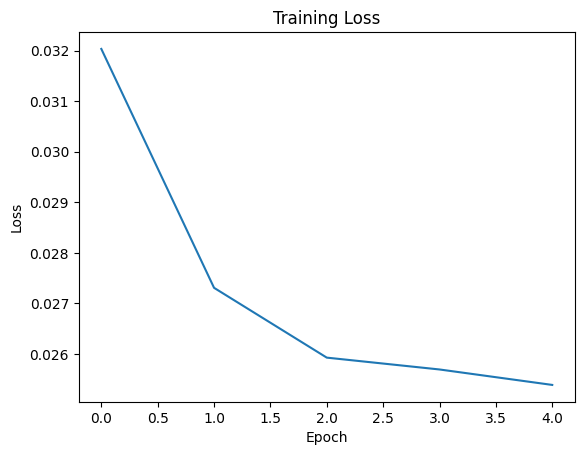

In [ ]:
plt.plot(train_history[0])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Сохранение модели

In [ ]:
torch.save(vae, "./VAEGenerate.pth")

###Генерация изображений

Загрузка модели

In [ ]:
model = torch.load("./VAEGenerate.pth")

<ipython-input-35-dc3b6dd614bc>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("./VAEGenerate.pth")


Генерация изображений

In [ ]:
mu1 = torch.Tensor([
    [0.1, 0.2, 0.1, 0.32, 0.231, 0.543, 0.111, 0.12, 0.32, 0.12]
])
log_Var1 = torch.Tensor([
    [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
])
#mu1= mu1.to(device)
#log_Var1 = log_Var1.to(device)
genered1 = model.generate(mu=mu1, log_var=log_Var1)

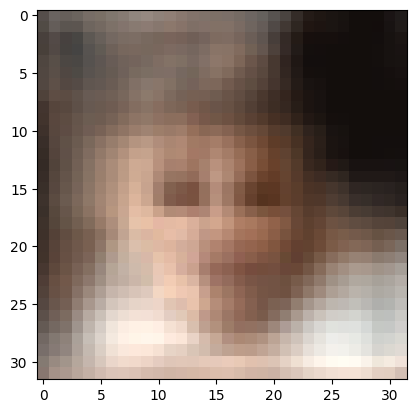

In [ ]:
#genered1.to('cpu')
genered1 = torch.transpose(genered1, 3, 1)
genered1 = torch.transpose(genered1, 1, 2)

genered1 = genered1[0].detach().numpy()
plt.imshow(genered1)

In [ ]:
mu2 = torch.Tensor([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
])
log_Var2 = torch.Tensor([
    [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
])
genered2 = vae.generate(mu=mu2, log_var=log_Var2)

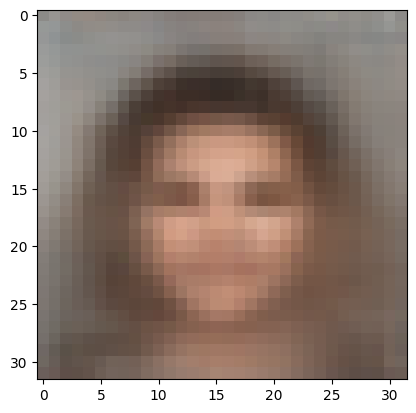

In [ ]:
genered2 = torch.transpose(genered2, 3, 1)
genered2 = torch.transpose(genered2, 1, 2)
genered2 = genered2[0].detach().numpy()
plt.imshow(genered2)

##Выводы

В заключении данного иследования отметим, что основопологающие концепции вариационных автокодировщиков представлены как нейронные сети для сжатия и восстановления данных, что позволяет глубже понять VAE.

Результаты обучения были представлены в виде сгенерированных изображений.

*Проблемы VAE*

Недостатком VAE является то, что они генерируют размытые реконструкции и нереалистичные результаты. Однако, помимо генерации изображений вариационные автокодировщики отлично справляются с задачами обнаружения аномалий, заполнения пропущенных значений и тд.

*Возможные улучшения*

Для создания изображений лучше использовать GAN, так как они генерируют образцы высокого качества.




Список литературы:

[Geeksforgeeks](https://www.geeksforgeeks.org/variational-autoencoders/)